# Check project structure

In [1]:
%%sh
# apt-get update
# apt-get install tree 
tree -L 3

.
├── 1-explore-dataset.ipynb
├── 2-pipeline_v1.ipynb
├── best_pipeline_config.json
├── best_pipeline_config_tank_130_lee_sigma_canny_tank_multi_scale_tank_score_1.000.json
├── best_pipeline_config_tank_34_lee_sigma_canny_tank_multi_scale_tank_score_1.000.json
├── oil_tank_analyzer
│   ├── TODO.md
│   ├── __init__.py
│   ├── __pycache__
│   │   └── __init__.cpython-310.pyc
│   ├── ai
│   │   ├── __pycache__
│   │   └���─ circle_detector.py
│   ├── core
│   │   ├── __init__.py
���   │   ├── __pycache__
│   │   ├── base_processor.py
│ �� │   ├── config.py
│   │   └── types.py
│   ├── detection
│   │   ├── __pycache__
│   │   ├── circle_detectors.py
│   │   └── edge_detectors.py
│   ├── pipelines
│   │��  ├── __pycache__
│   │   └── tank_pipeline.py
│   ├── preprocessing
│   │   ├── __pycache__
│   │   ├── denoisers.py
│   │   └── preprocessors.py
│   ├── scripts
���   │   └── process_tanks.py
│   └── utils
│       ├── __init__.py
│       ├── __pycache__
│       ├── annotation_processor.p

# Paths

In [2]:
from pathlib import Path

DATA_PATH = Path("/app/data/oil_tank_volume/oiltank")
RAW_DATA_PATH = DATA_PATH / "raw_data"
PROCESSED_DATA_PATH = DATA_PATH/"processed_data"

# Enumerate annoation

In [2]:
from oil_tank_analyzer.utils.annotation_processor import AnnotationEnumerator
AnnotationEnumerator().process_all_geojsons_recursive(RAW_DATA_PATH, PROCESSED_DATA_PATH)

Enumerated GeoJSON saved to: /app/data/oil_tank_volume/oiltank/processed_data/ICEYE_ARCHIVE_SLH_184360_20211203T092646/ICEYE_ARCHIVE_SLH_184360_20211203T092646.geojson
Enumerated GeoJSON saved to: /app/data/oil_tank_volume/oiltank/processed_data/ICEYE_ARCHIVE_SLH_184360_20211203T092646/tiles/ICEYE_ARCHIVE_SLH_184360_20211203T092646_48/ICEYE_ARCHIVE_SLH_184360_20211203T092646_48.geojson
Enumerated GeoJSON saved to: /app/data/oil_tank_volume/oiltank/processed_data/ICEYE_ARCHIVE_SLH_184360_20211203T092646/tiles/ICEYE_ARCHIVE_SLH_184360_20211203T092646_121/ICEYE_ARCHIVE_SLH_184360_20211203T092646_121.geojson
Enumerated GeoJSON saved to: /app/data/oil_tank_volume/oiltank/processed_data/ICEYE_ARCHIVE_SLH_184360_20211203T092646/tiles/ICEYE_ARCHIVE_SLH_184360_20211203T092646_43/ICEYE_ARCHIVE_SLH_184360_20211203T092646_43.geojson
Enumerated GeoJSON saved to: /app/data/oil_tank_volume/oiltank/processed_data/ICEYE_ARCHIVE_SLH_184360_20211203T092646/tiles/ICEYE_ARCHIVE_SLH_184360_20211203T092646_1

# Select and rotate annotation

Loaded 7 annotations
Processing 7 oil tanks...

PROCESSING RESULTS SUMMARY
1. Tank 34: Height: 159.88m, Diameter: 107.50m, Aspect: 1.49 (OBB) | Rotation: -76.8° | Shape: (330, 206)
2. Tank 35: Height: 162.15m, Diameter: 110.58m, Aspect: 1.47 (OBB) | Rotation: -77.5° | Shape: (335, 211)
3. Tank 36: Height: 165.10m, Diameter: 108.26m, Aspect: 1.53 (OBB) | Rotation: -76.7° | Shape: (340, 207)
4. Tank 37: Height: 159.87m, Diameter: 113.04m, Aspect: 1.41 (OBB) | Rotation: -76.3° | Shape: (330, 217)
5. Tank 39: Height: 164.94m, Diameter: 113.16m, Aspect: 1.46 (OBB) | Rotation: -76.8° | Shape: (340, 216)
6. Tank 40: Height: 162.01m, Diameter: 108.17m, Aspect: 1.50 (OBB) | Rotation: -75.4° | Shape: (334, 207)
7. Tank 65: Height: 128.81m, Diameter: 80.97m, Aspect: 1.59 (OBB) | Rotation: -80.3° | Shape: (267, 155)


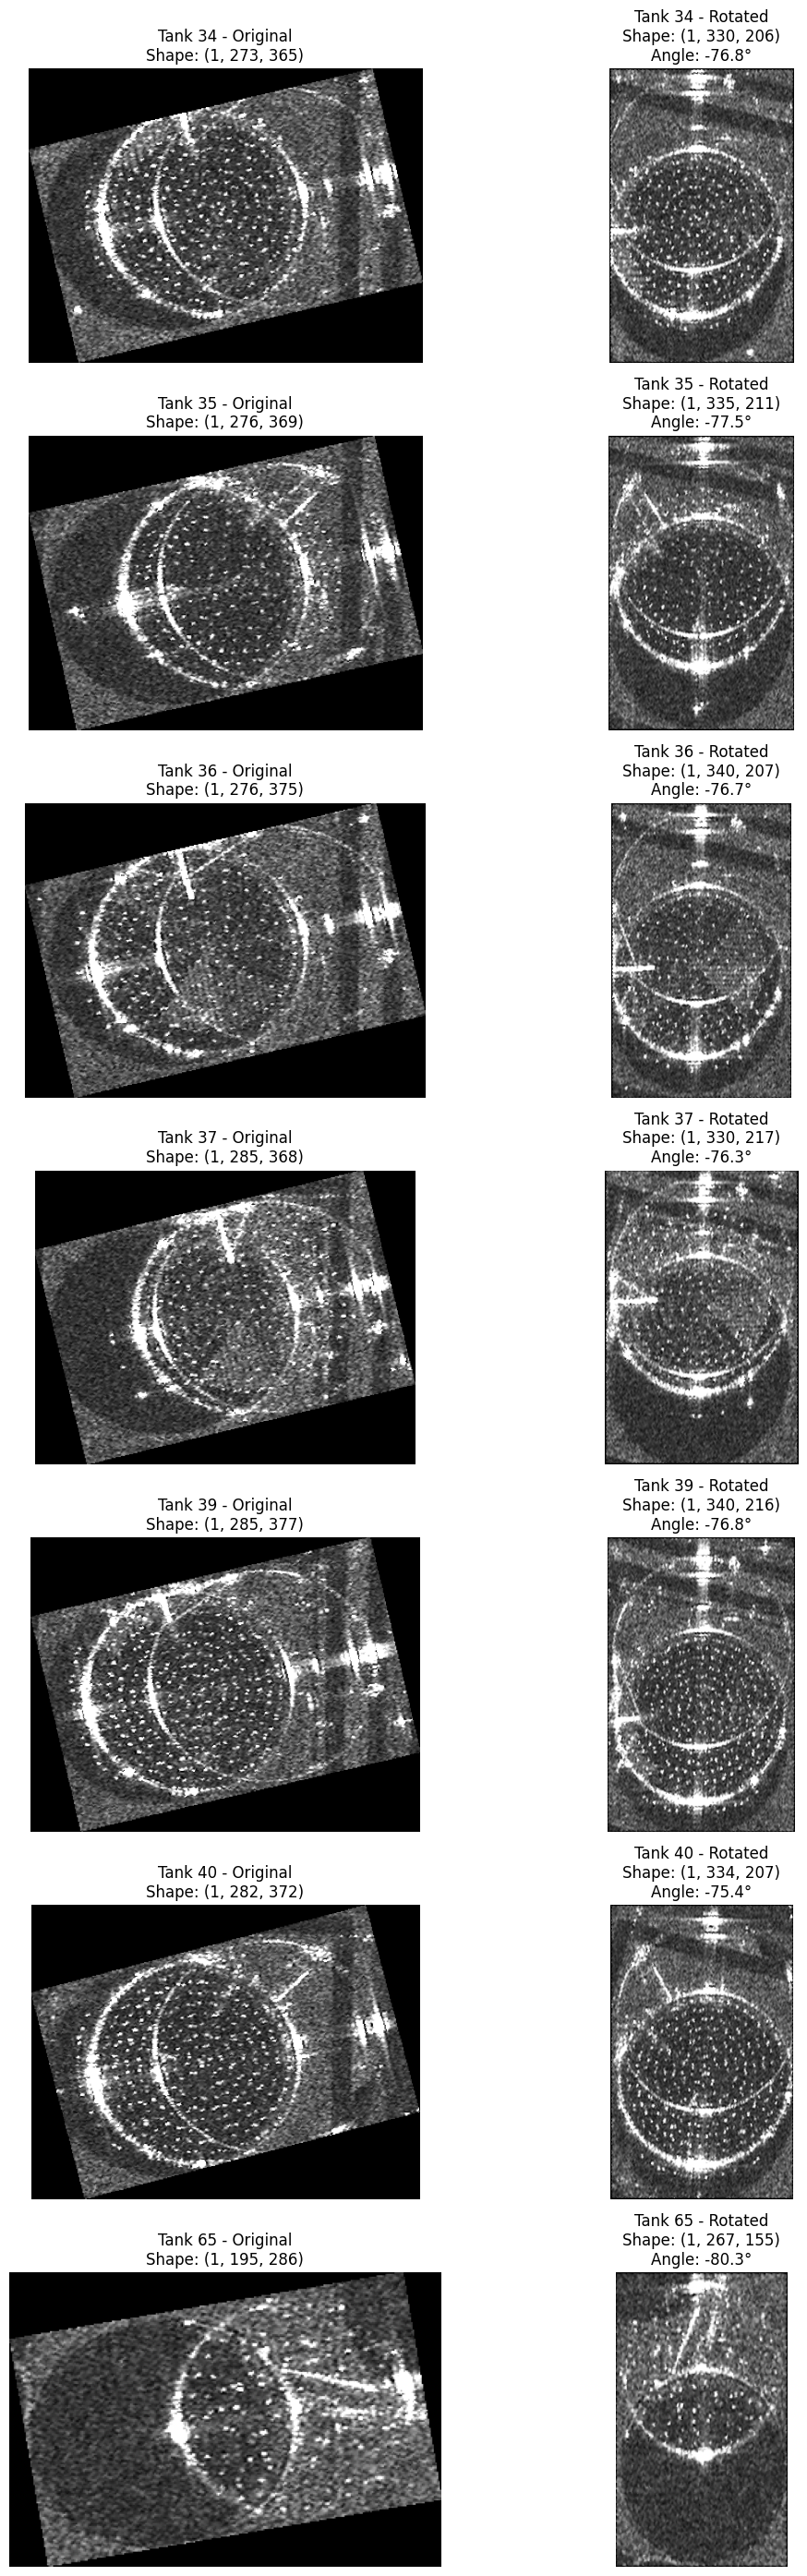


FINAL SUMMARY
   annotation_id    height_m  diameter_m vertical_direction measurement_type
0             34  159.877301  107.503592               down              OBB
1             35  162.148772  110.583681               down              OBB
2             36  165.097478  108.256891               down              OBB
3             37  159.866513  113.035581               down              OBB
4             39  164.942744  113.163756               down              OBB
5             40  162.005797  108.173104                 up              OBB
6             65  128.811451   80.972683               down              OBB


In [3]:
from pathlib import Path
from typing import List, Optional
from oil_tank_analyzer.core.types import ProcessedTank
import geopandas as gpd
from oil_tank_analyzer.utils.annotation_processor import process_tank_batch, create_results_dataframe, visualize_tank_comparison, display_processing_results

selected_image = "ICEYE_ARCHIVE_SLH_184358_20211201T092638"
selected_ids = [34,35,36,37,39,40,65] #[130, 131, 132, 133] [34,35,36,37,39,40,65] None

raster_path = RAW_DATA_PATH / selected_image / f"{selected_image}.tif"
annotation_path = PROCESSED_DATA_PATH / selected_image / f"{selected_image}.geojson"

processed_tanks: List[ProcessedTank]
results_df: gpd.GeoDataFrame

# Process tanks 
processed_tanks = process_tank_batch(raster_path, annotation_path, selected_ids, verbose=False)

# Create GeoDataFrame
results_df = create_results_dataframe(processed_tanks)

# Visualize
display_processing_results(processed_tanks, max_display=10)
visualize_tank_comparison(processed_tanks, max_display=10)

# Save if needed
results_df.to_file("oil_tanks_processed_results.geojson", driver='GeoJSON')

# Print final summary
print("\n" + "="*50)
print("FINAL SUMMARY")
print("="*50)
print(results_df[['annotation_id', 'height_m', 'diameter_m', 'vertical_direction', 'measurement_type']])

## Inspect results 

In [8]:
results_df.head()

,annotation_id,geometry,height_m,diameter_m,rotation_angle,vertical_direction,aspect_ratio,pixel_resolution,measurement_type
0,34,"POLYGON ((52.69036 24.10981, 52.68883 24.10946...",159.877301,107.503592,-76.794688,down,1.487181,0.511362,OBB
1,35,"POLYGON ((52.68855 24.10988, 52.68700 24.10954...",162.148772,110.583681,-77.453741,down,1.466299,0.511362,OBB
2,36,"POLYGON ((52.68675 24.10988, 52.68517 24.10951...",165.097478,108.256891,-76.741369,down,1.525053,0.511362,OBB
3,37,"POLYGON ((52.68676 24.11241, 52.68524 24.11204...",159.866513,113.035581,-76.252144,down,1.414303,0.511362,OBB
4,39,"POLYGON ((52.69045 24.11238, 52.68887 24.11201...",164.942744,113.163756,-76.833840,down,1.457558,0.511362,OBB


In [35]:
# from dataclasses import fields

# print("Dataclass fields:")
# for field in fields(processed_tanks[0]):
#     print(f"  {field.name}: {getattr(processed_tanks[0], field.name)}")

dir(processed_tanks[0])

['__annotations__',
 '__class__',
 '__dataclass_fields__',
 '__dataclass_params__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__match_args__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 'annotation_id',
 'geometry',
 'measurements',
 'non_rotated_crop',
 'pixel_resolution',
 'rotated_crop',
 'rotation_angle',
 'shape',
 'vertical_direction']

# Optimize pipeline

In [ ]:
from oil_tank_analyzer.utils.pipeline_optimizer import PipelineOptimizer
from oil_tank_analyzer.utils.optimization_reporter import OptimizationReporter

# Run complete optimization
optimizer = PipelineOptimizer(verbose=True, random_seed=42)
final_results, best_config = optimizer.run_optimization_pipeline(processed_tanks = processed_tanks, 
                                                                test_tank_index=0, 
                                                                strategies = ['recommended', 'smart', 'exhaustive'], 
                                                                shuffle = True,
                                                                max_configs_per_strategy = [20, 40, 50],  
                                                                top_k_final=100)

=== OIL TANK GRID SEARCH OPTIMIZATION ===
Using tank 34 for optimization
Test image shape: (330, 206)
Strategies: ['recommended', 'smart', 'exhaustive']
Shuffle: True
Max configs per strategy: [20, 40, 50]

--- Testing strategy: RECOMMENDED ---
Max configurations: 20
Shuffle: True
Generated 7 recommended configurations
Shuffled 7 configurations
Testing 7 configurations...
Configurations are shuffled
Config 1/7: tank_enhancement + lee_sigma + canny_tank + hough_tank
  Preprocess params: {}
  Denoise params: {}
  Edge params: {}
  Circle params: {}
Preprocessing with tank_enhancement...
Preprocessed - Shape: (330, 206), dtype: uint8, range: [2, 255]
Denoising with lee_sigma...
Denoised - Shape: (330, 206), dtype: uint8, range: [47, 230]
Edge detection with canny_tank...
Edges - Shape: (330, 206), dtype: uint8, range: [0, 255]
Circle detection with hough_tank...
Detected 1 circles
  → Score: 0.167, Circles: 1, Identified: 1
--------------------------------------------------

Config 2/7: i

In [10]:
# Generate report and save best config
OptimizationReporter.generate_summary_report(final_results, processed_tanks[0].rotated_crop.shape, processed_tanks[0].annotation_id)
OptimizationReporter.save_best_configuration(best_config, processed_tanks[0].annotation_id, final_results[0]['score'])


=== GRID SEARCH SUMMARY REPORT ===
Target Tank: 34
Image Shape: (1, 330, 206)
Total Configurations: 100

Method Frequency in Top 100 Configurations:
Denoising Methods:
  lee_sigma: 36 configurations
  frost: 30 configurations
  median_tank: 16 configurations
  enhanced_lee: 14 configurations
  sar_bilateral: 4 configurations
Edge Detection Methods:
  canny_tank: 36 configurations
  adaptive_threshold_tank: 30 configurations
  morphological_tank: 16 configurations
  combined_tank: 13 configurations
  multi_scale_tank: 5 configurations
Circle Detection Methods:
  multi_scale_tank: 37 configurations
  hough_tank: 31 configurations
  contour_tank: 17 configurations
  ellipse_tank: 14 configurations
  intensity_tank: 1 configurations

Score Statistics:
  Best: 1.000
  Worst: 0.000
  Average: 0.472
  Std Dev: 0.427
Success Rate (score > 0.5): 35.0%

Best configuration saved to best_pipeline_config_tank_34_lee_sigma_canny_tank_multi_scale_tank_score_1.000.json


'best_pipeline_config_tank_34_lee_sigma_canny_tank_multi_scale_tank_score_1.000.json'

# Quick test

Testing configuration: tank_enhancement + enhanced_lee + xarray_contour_edges + multi_scale_tank
  Preprocess params: {'enhance_contrast': True, 'enhance_circular': True, 'suppress_background': False, 'clahe_clip_limit': 2.0, 'clahe_grid_size': 8, 'dog_sigma1': 1.0, 'dog_sigma2': 2.0}
  Denoise params: {'window_size': 7, 'damping_factor': 1.0, 'cu': 0.523, 'max_sigma': 2.0, 'enhance_circular': True, 'edge_preserving': True, 'circular_kernel_size': 3, 'edge_threshold': 0.1, 'preserve_dynamic_range': True}
  Edge params: {'levels': 3, 'robust': True, 'clean_edges': True, 'enhance_contrast': True, 'reduce_speckle': True, 'remove_small_edges': True, 'min_edge_length': 20, 'enhance_horizontal': True}
  Circle params: {'center_tolerance': 0.2, 'min_diameter_ratio': 0.6, 'max_diameter_ratio': 1.1, 'max_circles': -1}
Preprocessing with tank_enhancement...
Preprocessed - Shape: (330, 217), dtype: uint8, range: [2, 255]
Denoising with enhanced_lee...
Denoised - Shape: (330, 217), dtype: uint8, r

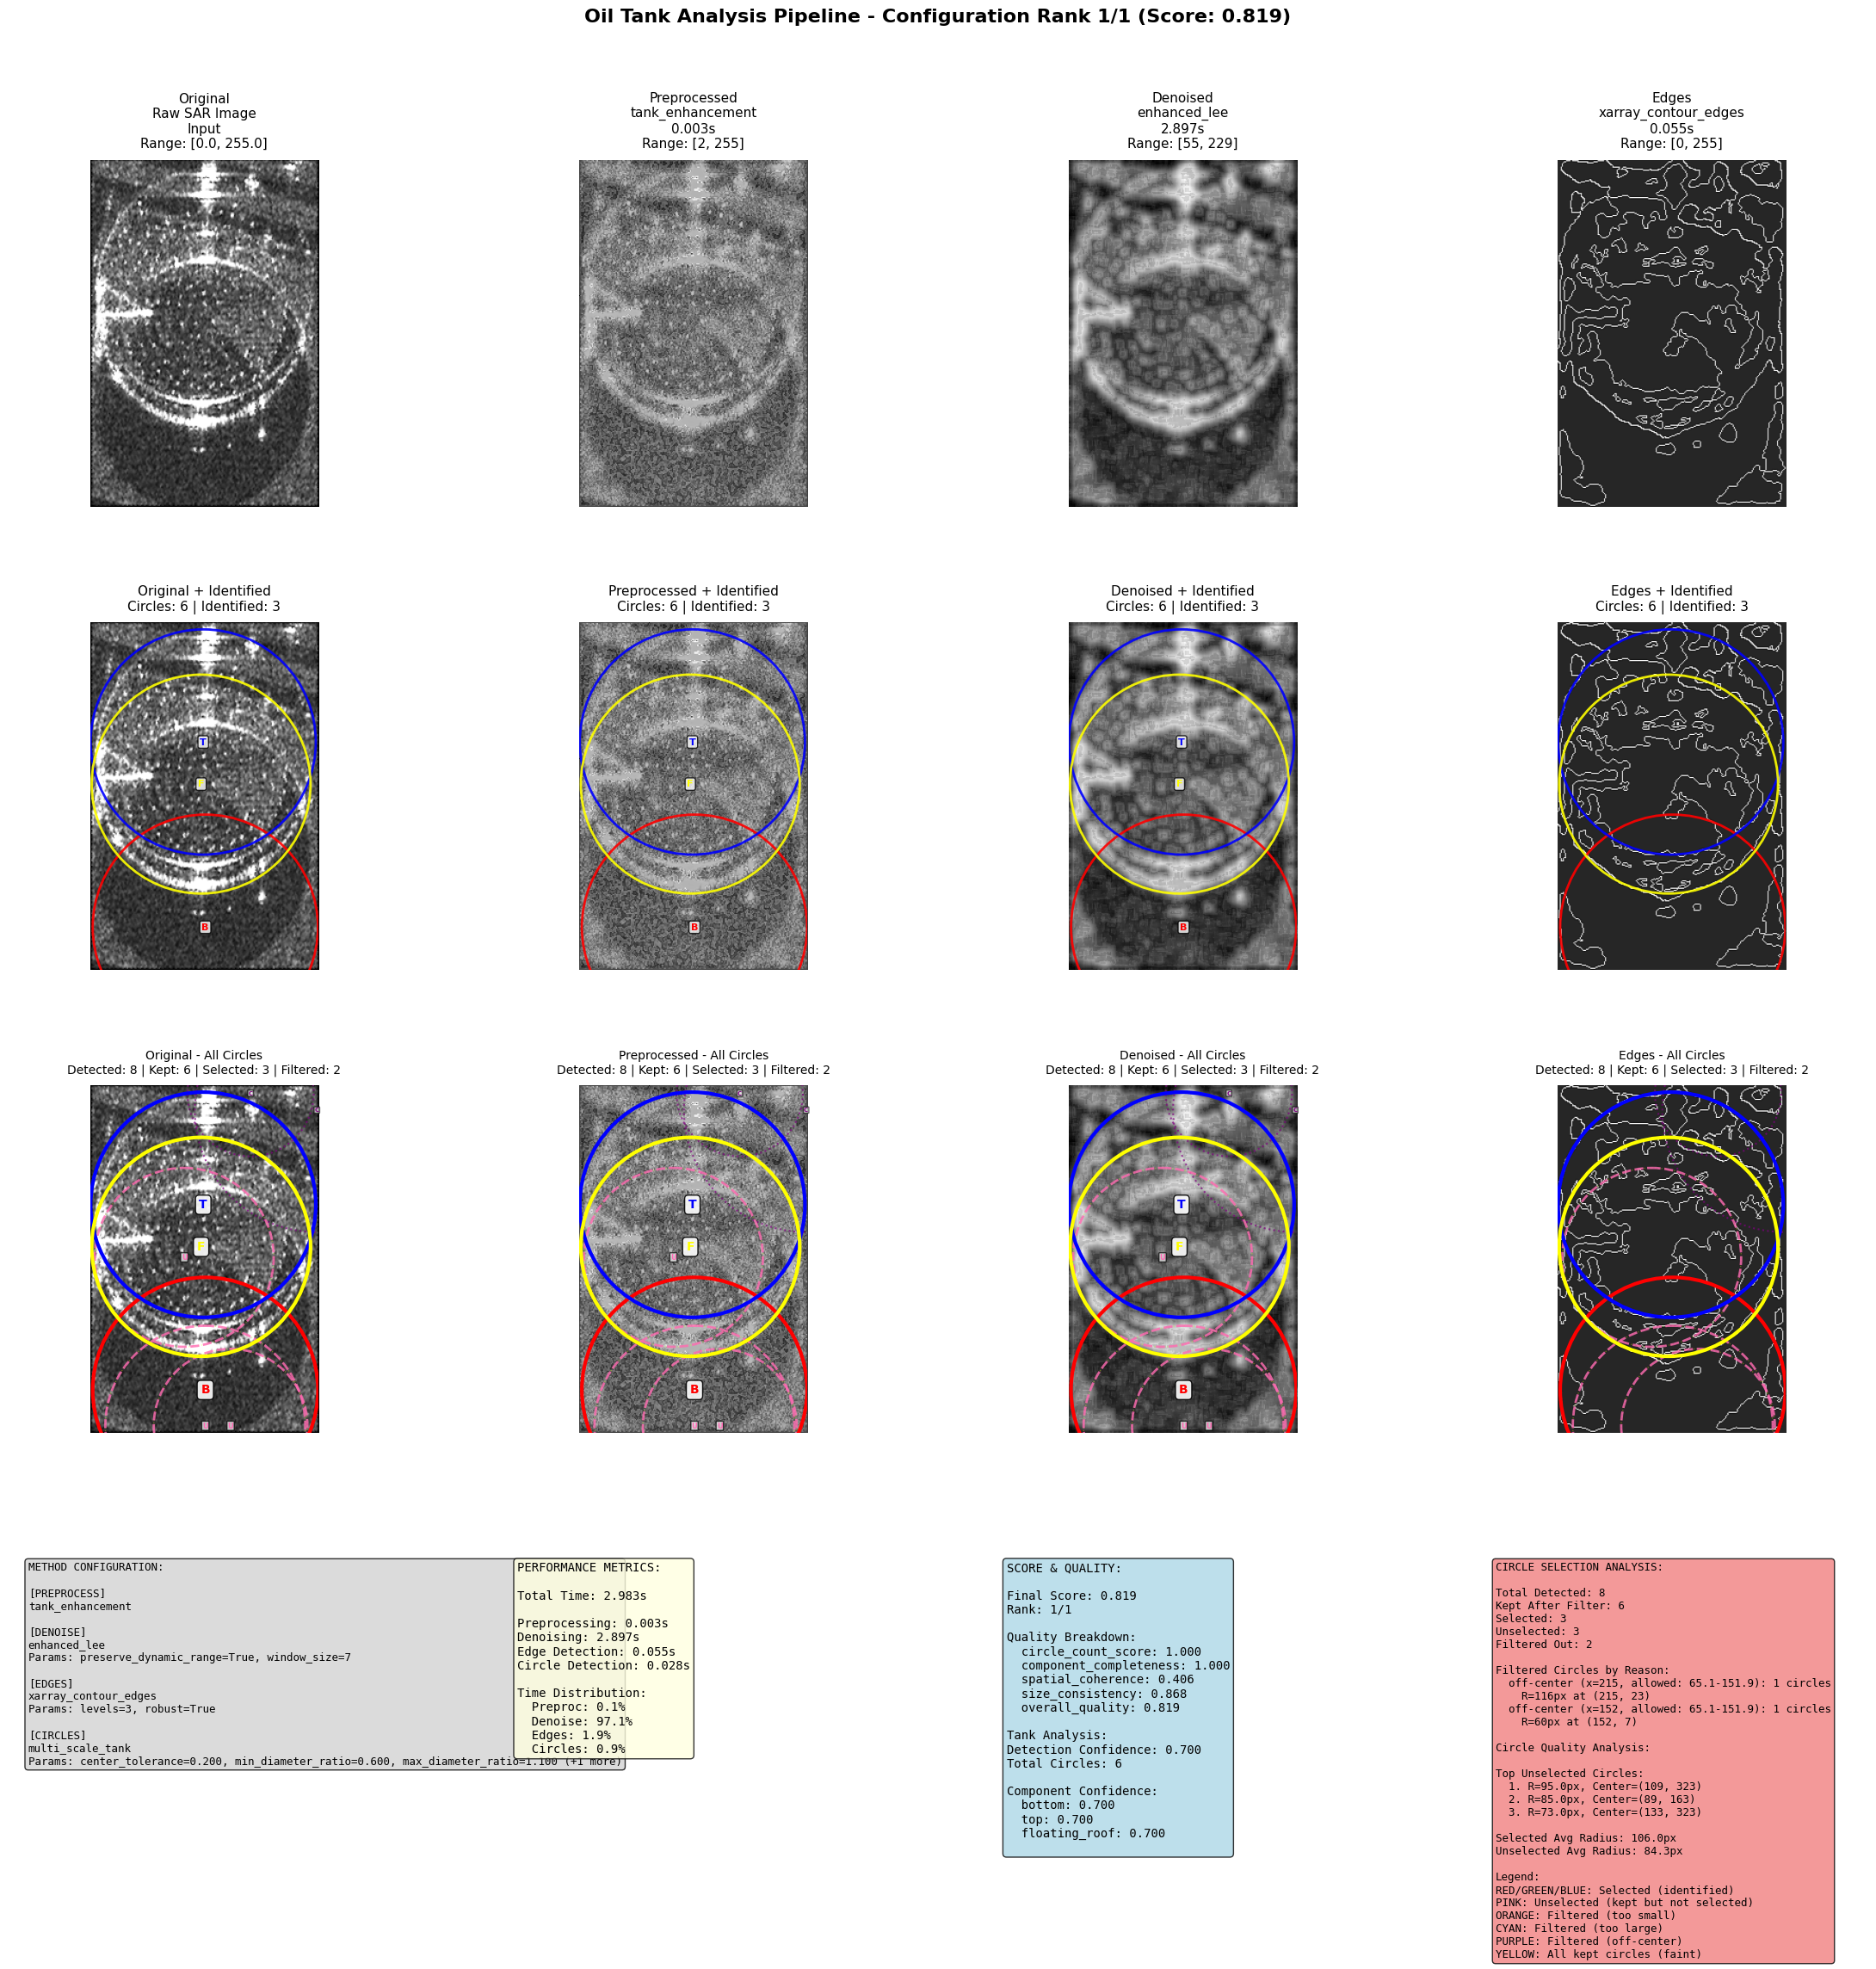

In [8]:
from oil_tank_analyzer.utils.pipeline_optimizer import quick_test_configuration
r= quick_test_configuration(
    processed_tanks,
    
    preprocessing_method='tank_enhancement', #['identity_preprocessor', 'basic_normalization', 'tank_enhancement', 'multi_scale_enhancement']
    denoise_method='enhanced_lee',
    edge_method='xarray_contour_edges',
    circle_method='multi_scale_tank', #['hough_tank', 'ellipse_tank', 'contour_tank', 'multi_scale_tank', 'template_tank', 'intensity_tank', 'blob_detector']
    
    preprocessing_params={}, 
    denoise_params={'preserve_dynamic_range': True, 'window_size': 7},  # Smaller window = less smoothing
    edge_params={'levels': 3, 'robust': True},
    circle_params={'center_tolerance': 0.2, 'min_diameter_ratio': 0.6, 'max_diameter_ratio': 1.1, 'max_circles': -1},
    
    tank_index=3
)

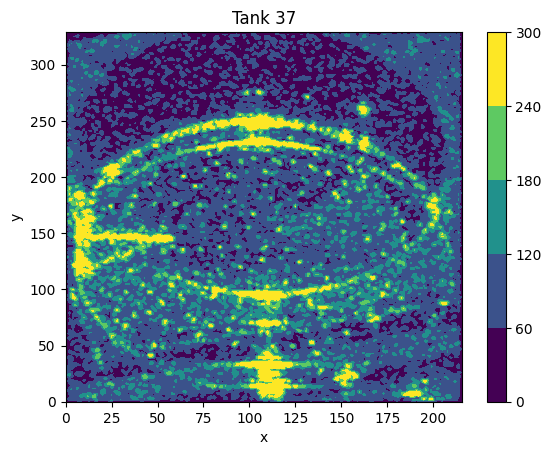

In [20]:
import xarray as xr
import matplotlib.pyplot as plt
# Super minimal test
tank_idx = 3
image = processed_tanks[tank_idx].rotated_crop[0] if processed_tanks[tank_idx].rotated_crop.shape[0] == 1 else processed_tanks[tank_idx].rotated_crop[0]

# Create and plot
da = xr.DataArray(image, dims=['y', 'x'], coords={'y': range(image.shape[0]), 'x': range(image.shape[1])})
da.plot.contourf(x="x", y="y", robust=True, levels=5, cmap="viridis")
plt.title(f"Tank {processed_tanks[tank_idx].annotation_id}")
plt.show()